# 🧬 ARC (Adaptive Retention & Correction) — MolFormer Continual Learning
### Corrected Implementation | Multi-Label Molecular Toxicity

**Pipeline:**  
`Raw CSV → SMILES Cleaning → Preprocessing → Scaffold Split → Unified Combined Dataset → MolFormer Sequential Training → ARC (Fixed OTD + Retention + Correction) → Full CL Metrics`

**Datasets:** ToxCast (26 labels) | Tox21 (12 labels) | SIDER (26 labels)  
**Model:** MolFormer (frozen backbone) + Linear Classifier  
**ARC Fixes:** Correct OTD routing · Correct w=c/c_hat ratio · Paper-accurate TSS · Unified test set · Per-sample optimizer reset  
**Metrics:** AUROC | AB (Average Accuracy) | Forgetting (F) | BWT | FWT


In [1]:
import sys
print(sys.executable)

import torch
print("======== GPU CHECK ========")
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version (torch):", torch.version.cuda)
else:
    print("❌ GPU not detected. Using CPU")
print("===========================")


/home/student/miniforge3/envs/molformer/bin/python
======== GPU CHECK ========
CUDA available: True
GPU count: 1
GPU name: Tesla V100S-PCIE-32GB
CUDA version (torch): 12.1


In [2]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    'torch>=2.0.0',
    'transformers>=4.35.0',
    'scikit-learn>=1.3.0',
    'numpy>=1.24.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'pandas>=2.0.0',
    'rdkit',
    'einops',
    'rotary-embedding-torch',
    'requests',
    'scipy',
]

for pkg in packages:
    try:
        install(pkg)
        print(f'  ✓ {pkg}')
    except Exception as e:
        print(f'  ✗ {pkg}: {e}')

print('\nInstallation complete. Restart kernel if first run.')


  ✓ torch>=2.0.0


  ✓ transformers>=4.35.0


  ✓ scikit-learn>=1.3.0


  ✓ numpy>=1.24.0


  ✓ matplotlib>=3.7.0


...

  ✓ rdkit


  ✓ einops


  ✓ rotary-embedding-torch


  ✓ requests


  ✓ scipy

Installation complete. Restart kernel if first run.


In [1]:
# ============================================================
# CELL 2 — GLOBAL IMPORTS
# ============================================================
import os, warnings, copy, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import roc_auc_score
from scipy.stats import sem
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports done | Device: {DEVICE}")


✅ Imports done | Device: cuda


In [2]:
# ============================================================
# CELL 3 — GLOBAL CONFIG
# ============================================================

CONFIG = {
    # ── File paths (UPDATE THESE) ──
    "tox21_path":   "tox21.csv",
    "sider_path":   "sider.csv",
    "toxcast_path": "toxcast_data.csv",

    # MolFormer HuggingFace model
    "molformer_name": "ibm/MoLFormer-XL-both-10pct",

    # Training
    "batch_size":  32,
    "lr_head":     1e-3,
    "epochs":      20,
    "max_length":  128,
    "seed":        42,

    # ── ARC Thresholds (paper ablation: robust in 0.6–0.9 range) ──
    # FIXED: These now match paper's actual Assumptions 1 & 2
    "epsilon":   0.75,   # Assumption 1 — Retention: high confidence on past class
    "theta":     1.5,    # Assumption 2 — Correction: w = c/c_hat < theta
    "tss_temp":  2.0,    # TSS temperature T > 1 (paper default)

    # Label filtering
    "nan_threshold":     0.5,   # drop cols with >50% NaN
    "density_threshold": 0.03,  # keep labels with >3% positive rate (ToxCast)
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

print("✅ Config set")
print(json.dumps({k: v for k, v in CONFIG.items()
                  if k not in ["tox21_path","sider_path","toxcast_path"]}, indent=2))


✅ Config set
{
  "molformer_name": "ibm/MoLFormer-XL-both-10pct",
  "batch_size": 32,
  "lr_head": 0.001,
  "epochs": 20,
  "max_length": 128,
  "seed": 42,
  "epsilon": 0.75,
  "theta": 1.5,
  "tss_temp": 2.0,
  "nan_threshold": 0.5,
  "density_threshold": 0.03
}


## 📥 Section 1: Data Loading, Preprocessing & Unified Dataset Setup

In [3]:
# ============================================================
# CELL 4 — LOAD CSV FILES
# ============================================================
def load_csv(path, name):
    print(f"\n📥 Loading {name}...")
    df = pd.read_csv(path)
    print(f"✅ {name} loaded | Shape: {df.shape}")
    return df

tox21_df   = load_csv(CONFIG["tox21_path"],   "Tox21")
sider_df   = load_csv(CONFIG["sider_path"],   "SIDER")
toxcast_df = load_csv(CONFIG["toxcast_path"], "ToxCast")



📥 Loading Tox21...
✅ Tox21 loaded | Shape: (7831, 15)

📥 Loading SIDER...
✅ SIDER loaded | Shape: (1427, 28)

📥 Loading ToxCast...
✅ ToxCast loaded | Shape: (8576, 618)


In [4]:
# ============================================================
# CELL 5 — SMILES CLEANING (RDKit canonical + invalid removal)
# ============================================================
def clean_smiles_column(df, smiles_col="SMILES"):
    cleaned, valid_idx = [], []
    for idx, smi in tqdm(enumerate(df[smiles_col]), total=len(df)):
        if pd.isna(smi) or smi == "":
            continue
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            continue
        cleaned.append(Chem.MolToSmiles(mol))
        valid_idx.append(idx)
    df_clean = df.iloc[valid_idx].copy()
    df_clean[smiles_col] = cleaned
    df_clean.reset_index(drop=True, inplace=True)
    print(f"Original: {len(df)} | Valid: {len(df_clean)} | Removed: {len(df)-len(df_clean)}")
    return df_clean

tox21_clean   = clean_smiles_column(tox21_df)
sider_clean   = clean_smiles_column(sider_df)
toxcast_clean = clean_smiles_column(toxcast_df)

tox21_clean   = tox21_clean.drop_duplicates(subset="SMILES").reset_index(drop=True)
sider_clean   = sider_clean.drop_duplicates(subset="SMILES").reset_index(drop=True)
toxcast_clean = toxcast_clean.drop_duplicates(subset="SMILES").reset_index(drop=True)

print("\n✅ Final sizes after dedup:")
print(f"  Tox21: {len(tox21_clean)} | SIDER: {len(sider_clean)} | ToxCast: {len(toxcast_clean)}")


  0%|          | 0/7831 [00:00<?, ?it/s]

[18:29:38] WARNING: not removing hydrogen atom without neighbors
 27%|██▋       | 2145/7831 [00:00<00:01, 5354.83it/s][18:29:38] Explicit valence for atom # 3 Al, 6, is greater than permitted
[18:29:38] Explicit valence for atom # 4 Al, 6, is greater than permitted
 56%|█████▌    | 4350/7831 [00:00<00:00, 5448.00it/s][18:29:39] Explicit valence for atom # 9 Al, 6, is greater than permitted
[18:29:39] Explicit valence for atom # 5 Al, 6, is greater than permitted
100%|██████████| 7831/7831 [00:01<00:00, 5322.19it/s]


Original: 7831 | Valid: 7823 | Removed: 8


  0%|          | 0/1427 [00:00<?, ?it/s][18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
[18:29:39] WARNING: not removing hydrogen atom without neighbors
 44%|████▎     | 623/1427 [00:00<00:00, 3121.90it/s][18:29:40] WARNING: not removing hydrogen atom without neighbors
[18:29:40] WARNING: not removing hydrogen atom without neighbors
[18:29:40] WARNING: not removing hydrogen atom without neighbors
 71%|███████   | 1007/1427 [00:00<00:00, 3447.49it/s][18:29:40] WARNING: not removing hydrogen atom without neighbors
[18:29:40] WARNING: not removing hydrogen atom without neighbors
100%|█████

Original: 1427 | Valid: 1427 | Removed: 0


100%|██████████| 8576/8576 [00:01<00:00, 5224.80it/s]


Original: 8576 | Valid: 8576 | Removed: 0

✅ Final sizes after dedup:
  Tox21: 7823 | SIDER: 1427 | ToxCast: 8576


In [5]:
# ============================================================
# CELL 6 — PREPROCESSING: NaN handling + column filtering
# ============================================================
def preprocess_dataset(df, name, nan_threshold=0.5):
    print(f"\n⚙️  Preprocessing {name}...")
    df = df.copy()
    df.replace(-1, np.nan, inplace=True)

    non_label = ["SMILES", "mol_id", "Label"]
    label_cols = [c for c in df.columns if c not in non_label]

    nan_ratio = df[label_cols].isna().mean()
    keep_cols = nan_ratio[nan_ratio < nan_threshold].index.tolist()
    df = df[["SMILES"] + keep_cols].copy()
    print(f"  ✅ Kept {len(keep_cols)} labels after NaN filtering")

    df.dropna(subset=keep_cols, how="all", inplace=True)
    df[keep_cols] = df[keep_cols].fillna(0)
    df.reset_index(drop=True, inplace=True)
    print(f"  Final shape: {df.shape}")
    return df, keep_cols

def filter_labels_by_density(df, label_cols, threshold=0.03):
    density = df[label_cols].sum() / len(df)
    keep = density[density > threshold].index.tolist()
    print(f"  Density filter: kept {len(keep)}/{len(label_cols)} labels")
    return keep

tox21_clean, tox21_labels     = preprocess_dataset(tox21_clean,   "Tox21",   CONFIG["nan_threshold"])
sider_clean, sider_labels     = preprocess_dataset(sider_clean,   "SIDER",   CONFIG["nan_threshold"])
toxcast_clean, toxcast_labels = preprocess_dataset(toxcast_clean, "ToxCast", CONFIG["nan_threshold"])

toxcast_labels = filter_labels_by_density(toxcast_clean, toxcast_labels, CONFIG["density_threshold"])
toxcast_labels = toxcast_labels[:26]
toxcast_clean  = toxcast_clean[["SMILES"] + toxcast_labels].copy()

print(f"\n📊 Final → Tox21: {len(tox21_labels)} labels | SIDER: {len(sider_labels)} labels | ToxCast: {len(toxcast_labels)} labels")



⚙️  Preprocessing Tox21...
  ✅ Kept 12 labels after NaN filtering
  Final shape: (7823, 13)

⚙️  Preprocessing SIDER...
  ✅ Kept 26 labels after NaN filtering
  Final shape: (1427, 27)

⚙️  Preprocessing ToxCast...
  ✅ Kept 100 labels after NaN filtering
  Final shape: (8222, 101)
  Density filter: kept 65/100 labels

📊 Final → Tox21: 12 labels | SIDER: 26 labels | ToxCast: 26 labels


In [6]:
# ============================================================
# CELL 7 — PREFIX LABEL NAMES (avoid collision across datasets)
# ============================================================

tox21_label_names   = ["tox21_"   + l for l in tox21_labels]
sider_label_names   = ["sider_"   + l for l in sider_labels]
toxcast_label_names = ["toxcast_" + l for l in toxcast_labels]

all_label_names = tox21_label_names + sider_label_names + toxcast_label_names

print(f"Total labels: {len(all_label_names)}")
print(f"  Tox21: {len(tox21_label_names)} | SIDER: {len(sider_label_names)} | ToxCast: {len(toxcast_label_names)}")


Total labels: 64
  Tox21: 12 | SIDER: 26 | ToxCast: 26


In [7]:
# ============================================================
# CELL 8 — BUILD UNIFIED COMBINED DATAFRAME
# FIX: Single combined df with ALL label columns (missing = 0)
# This is essential for ARC — unified test set for all tasks
# ============================================================

def build_combined_df(dfs_labels_list, all_label_names):
    """
    Takes list of (df, prefixed_label_names) tuples.
    Creates one unified DataFrame with all label columns.
    Missing label columns filled with 0.
    """
    frames = []
    for df, orig_labels, prefixed_labels in dfs_labels_list:
        # Rename original label cols to prefixed names
        rename_map = {orig: pref for orig, pref in zip(orig_labels, prefixed_labels)}
        sub = df[["SMILES"] + orig_labels].rename(columns=rename_map).copy()
        frames.append(sub)

    # Outer join on SMILES — missing labels become NaN → fill 0
    combined = pd.concat(frames, ignore_index=True, sort=False)
    combined[all_label_names] = combined[all_label_names].fillna(0.0)
    combined = combined[["SMILES"] + all_label_names].copy()
    combined.reset_index(drop=True, inplace=True)
    return combined

combined_df = build_combined_df(
    [
        (tox21_clean,   tox21_labels,   tox21_label_names),
        (sider_clean,   sider_labels,   sider_label_names),
        (toxcast_clean, toxcast_labels, toxcast_label_names),
    ],
    all_label_names
)

print(f"✅ Combined DataFrame: {combined_df.shape}")
print(f"   Molecules: {len(combined_df)} | Labels: {len(all_label_names)}")
print(f"   Label coverage (non-zero per label):")
coverage = (combined_df[all_label_names] > 0).sum()
print(f"     Tox21  labels avg coverage: {coverage[tox21_label_names].mean():.0f} molecules")
print(f"     SIDER  labels avg coverage: {coverage[sider_label_names].mean():.0f} molecules")
print(f"     ToxCast labels avg coverage: {coverage[toxcast_label_names].mean():.0f} molecules")


✅ Combined DataFrame: (17472, 65)
   Molecules: 17472 | Labels: 64
   Label coverage (non-zero per label):
     Tox21  labels avg coverage: 488 molecules
     SIDER  labels avg coverage: 812 molecules
     ToxCast labels avg coverage: 656 molecules


In [8]:
# ============================================================
# CELL 9 — SCAFFOLD SPLIT ON UNIFIED COMBINED DF
# FIX: Single scaffold split on combined_df — same train/test
# for all tasks (required for correct CL evaluation)
# ============================================================
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import random

def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split(df, train_ratio=0.7, val_ratio=0.15, seed=42):
    random.seed(seed)
    scaffolds = {}
    for i, smi in enumerate(df["SMILES"]):
        sc = generate_scaffold(smi)
        scaffolds.setdefault(sc, []).append(i)

    scaffold_sets = list(scaffolds.values())
    random.shuffle(scaffold_sets)

    n = len(df)
    train_cut = int(train_ratio * n)
    val_cut   = int((train_ratio + val_ratio) * n)

    train_idx, val_idx, test_idx = [], [], []
    for sc_group in scaffold_sets:
        if len(train_idx) + len(sc_group) <= train_cut:
            train_idx.extend(sc_group)
        elif len(train_idx) + len(val_idx) + len(sc_group) <= train_cut + (val_cut - train_cut):
            val_idx.extend(sc_group)
        else:
            test_idx.extend(sc_group)

    train = df.iloc[train_idx].reset_index(drop=True)
    val   = df.iloc[val_idx].reset_index(drop=True)
    test  = df.iloc[test_idx].reset_index(drop=True)

    print(f"Scaffold split → Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
    print(f"  No SMILES overlap between splits: "
          f"{len(set(train.SMILES) & set(test.SMILES)) == 0}")
    return train, val, test

# Single split on combined df
train_df, val_df, test_df = scaffold_split(combined_df, seed=CONFIG["seed"])

print(f"\n✅ Unified split done")
print(f"   train_df: {train_df.shape} | val_df: {val_df.shape} | test_df: {test_df.shape}")


[18:29:57] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:29:59] WARNING: not removing hydrogen atom without neighbors
[18:30:00] WARNING: not removing hydrogen atom without neighbors
[18:30:00] WARNING: not removing hydrogen atom without neighbors
[18:30:00] WARNING: not removing hydrogen atom without neighbors
[18:30:00] WARNING: not removing hydrogen atom without neighbors
[18:30:00] WARNING: not removing hydrogen atom without neighbors
[18:30:01] WARNING: not removing hydrogen atom without neighbors


Scaffold split → Train: 12230 | Val: 2621 | Test: 2621
  No SMILES overlap between splits: True

✅ Unified split done
   train_df: (12230, 65) | val_df: (2621, 65) | test_df: (2621, 65)


In [9]:
# ============================================================
# CELL 10 — DEFINE CONTINUAL TASKS (using prefixed label names)
# ============================================================

task_splits = [
    tox21_label_names,    # Task 1: 12 Tox21 labels
    sider_label_names,    # Task 2: 26 SIDER labels
    toxcast_label_names,  # Task 3: 26 ToxCast labels
]

task_boundaries = [
    [all_label_names.index(l) for l in task_splits[t]]
    for t in range(len(task_splits))
]

print("Task definitions:")
for t, (split, bounds) in enumerate(zip(task_splits, task_boundaries)):
    print(f"  Task {t+1}: {len(split)} labels | indices {bounds[0]}..{bounds[-1]}")


Task definitions:
  Task 1: 12 labels | indices 0..11
  Task 2: 26 labels | indices 12..37
  Task 3: 26 labels | indices 38..63


## 🧱 Section 2: Dataset Class & Model

In [10]:
# ============================================================
# CELL 11 — TOKENIZER INIT
# ============================================================
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    CONFIG["molformer_name"],
    trust_remote_code=True
)
print("✅ Tokenizer loaded")


✅ Tokenizer loaded


In [11]:
# ============================================================
# CELL 12 — DATASET CLASS
# ============================================================
from torch.utils.data import Dataset
import torch

class MolDataset(Dataset):
    def __init__(self, smiles_list, labels_array, tokenizer, max_length=128):
        self.smiles    = smiles_list
        self.labels    = torch.tensor(labels_array, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         self.labels[idx],
        }

print("✅ MolDataset defined")


✅ MolDataset defined


In [12]:
# ============================================================
# CELL 13 — MODEL: MolFormer + Linear Classifier
# Frozen backbone, only classifier trains
# ============================================================
import torch.nn as nn
from transformers import AutoModel

class MLARCModel(nn.Module):
    def __init__(self, model_name="ibm/MoLFormer-XL-both-10pct", num_labels=None):
        super().__init__()
        if num_labels is None:
            num_labels = len(all_label_names)

        self.backbone = AutoModel.from_pretrained(
            model_name, trust_remote_code=True
        )
        hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(hidden_size, num_labels)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

        # Freeze backbone — only classifier trains
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]          # CLS token
        logits = self.classifier(cls)
        return logits                               # shape: (B, num_labels)

def build_model(model_name, num_labels):
    model = MLARCModel(model_name=model_name, num_labels=num_labels).to(DEVICE)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Model loaded | Labels: {num_labels} | Trainable params: {trainable:,}")
    return model

print("✅ MLARCModel defined")


✅ MLARCModel defined


## 🔁 Section 3: Training Utilities

In [13]:
# ============================================================
# CELL 14 — EARLY STOPPING
# ============================================================
import copy

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0005):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience

print("✅ EarlyStopping defined")


✅ EarlyStopping defined


In [24]:
# ============================================================
# CELL 15 — CLASS WEIGHT & DATALOADER HELPERS
# ============================================================
import numpy as np
from torch.utils.data import DataLoader

def compute_class_weights(df, task_label_names):
    labels = df[task_label_names].values.astype(np.float32)
    labels = np.nan_to_num(labels, nan=0.0)
    pos = labels.sum(axis=0)
    neg = len(labels) - pos
    weights = neg / (pos + 1e-3)
    weights = np.clip(weights, 1.0, 100.0)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)

def make_task_dataloader(df, task_label_names, all_label_names,
                         tokenizer, batch_size=32, max_length=128):
    task_indices = [all_label_names.index(l) for l in task_label_names]
    smiles = df["SMILES"].tolist()
    labels = df[all_label_names].values.astype(np.float32)
    labels = np.nan_to_num(labels, nan=0.0)
    dataset = MolDataset(smiles, labels, tokenizer, max_length)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    return loader, task_indices

print("✅ Dataloader helpers defined")


✅ Dataloader helpers defined


In [14]:
# ============================================================
# CELL 16 — TRAIN TASK FUNCTION
# ============================================================
def train_task(model, tokenizer, df, task_label_names, all_label_names,
               task_id, epochs=20, batch_size=32):
    print(f"\n🔥 Training Task {task_id+1} ({len(task_label_names)} labels)")

    loader, task_indices = make_task_dataloader(
        df, task_label_names, all_label_names, tokenizer, batch_size
    )

    # Only classifier trains (backbone frozen)
    optimizer     = AdamW(model.classifier.parameters(), lr=CONFIG["lr_head"])
    class_weights = compute_class_weights(df, task_label_names)
    criterion     = nn.BCEWithLogitsLoss(pos_weight=class_weights)
    early_stopper = EarlyStopping(patience=7)

    model.train()
    for epoch in range(epochs):
        total_loss, n_batches = 0.0, 0
        for batch in loader:
            input_ids  = batch["input_ids"].to(DEVICE)
            attn_mask  = batch["attention_mask"].to(DEVICE)
            labels_all = batch["labels"].to(DEVICE)
            labels_task = labels_all[:, task_indices]

            optimizer.zero_grad()
            logits_all  = model(input_ids, attn_mask)
            logits_task = logits_all[:, task_indices]
            logits_task = torch.clamp(logits_task, -20, 20)

            loss = criterion(logits_task, labels_task)
            if torch.isnan(loss):
                print("⚠️ NaN loss — skipping batch")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.classifier.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        avg_loss = total_loss / max(n_batches, 1)
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

        if early_stopper.step(avg_loss, model):
            print(f"  ⛔ Early stopping at epoch {epoch+1}")
            break

    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)
        print("  ✅ Best model weights restored")

    return model

print("✅ train_task defined")


✅ train_task defined


## 🔥 Section 4: ARC Implementation — Fully Fixed

**All 3 critical bugs corrected:**
1. OTD routing: checks `predicted_class ∈ past/curr_indices` first (paper Assumptions 1 & 2)  
2. `w = c / c_hat` (was inverted before)  
3. TSS with temperature scaling (replaces naive ×0.5 suppression)  
4. Per-sample fresh optimizer for Adaptive Retention


In [16]:
# ============================================================
# CELL 17 — ARC: OUT-OF-TASK DETECTION (v3 — Fixed routing)
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np

arc_stats = {"retention": 0, "correction": 0, "none": 0}


def otd_detection(probs_tensor, past_indices, curr_indices, epsilon, theta):
    """
    Improved OTD: checks BOTH assumptions independently, not just
    based on which task the argmax lands on.

    Assumption 1 (Retention): max confidence over past-task labels > epsilon
    Assumption 2 (Correction): max confidence over current-task labels > 0,
        AND w = c_curr / c_past < theta (current task is low-confidence vs past)
    """
    if len(past_indices) == 0:
        return 'none', 0.0

    probs_np  = probs_tensor.detach().cpu().numpy()
    past_arr  = np.array(list(past_indices), dtype=int)
    curr_arr  = np.array(list(curr_indices), dtype=int)

    c_past = float(probs_np[past_arr].max())   # best confidence over past tasks
    c_curr = float(probs_np[curr_arr].max())   # best confidence over current task

    # Assumption 1: past-task class is highly confident → retention
    if c_past > epsilon:
        return 'retention', c_past

    # Assumption 2: current task fires but past tasks also have some signal
    #   w = c_curr / c_past. If w < theta the model is uncertain → correction
    if c_curr > 0.0 and c_past > 1e-8:
        w = c_curr / (c_past + 1e-8)
        if w < theta:
            return 'correction', w

    return 'none', 0.0


print("\u2705 OTD detection (v3 — fixed routing) defined")


✅ OTD detection (v3 — fixed routing) defined


In [17]:
# ============================================================
# CELL 18 — ADAPTIVE RETENTION (v3 — Fixed loss + sharpening)
# ============================================================
import copy

def adaptive_retention(model, input_ids, attn_mask, past_indices, curr_indices, lr=1e-4):
    """
    One gradient update on past-task output neurons only.
    Weights are RESTORED after the update (test-time only, no permanent change).
    Fixes:
      - Sharpen pseudo-labels with temperature 0.5 so BCE has a clear target
      - L_EM is entropy minimization: we WANT to reduce entropy (increase
        confidence), so we minimize entropy (positive value) directly
      - Gradient mask protects current-task rows
    """
    snapshot = copy.deepcopy(model.classifier.state_dict())

    opt = AdamW(model.classifier.parameters(), lr=lr)

    model.train()
    logits = model(input_ids, attn_mask)
    probs  = torch.sigmoid(logits).squeeze(0)

    past_idx_tensor = torch.tensor(past_indices, device=DEVICE)

    # Sharpen pseudo-labels: temperature 0.5 pushes soft probs toward 0/1
    # so BCE has a meaningful gradient to follow
    sharp_temp = 0.5
    p_detach = probs[past_idx_tensor].detach()
    pseudo = (p_detach ** (1.0 / sharp_temp))
    pseudo = pseudo / (pseudo + (1 - p_detach) ** (1.0 / sharp_temp) + 1e-8)
    pseudo = pseudo.clamp(0.0, 1.0)

    L_CE = F.binary_cross_entropy_with_logits(
        logits.squeeze(0)[past_idx_tensor], pseudo
    )

    # Entropy MINIMIZATION: minimize H(p) = -(p log p + (1-p) log(1-p))
    # H(p) is always >= 0. To MINIMIZE it, include it with a positive coefficient.
    p_clamped = probs[past_idx_tensor].clamp(1e-7, 1 - 1e-7)
    H = -(p_clamped * torch.log(p_clamped) + (1 - p_clamped) * torch.log(1 - p_clamped)).mean()

    loss = L_CE + 0.1 * H   # minimize CE + entropy (NOT maximize entropy)
    opt.zero_grad()
    loss.backward()

    # Protect current-task rows
    with torch.no_grad():
        for curr_idx in curr_indices:
            if model.classifier.weight.grad is not None:
                model.classifier.weight.grad[curr_idx, :] = 0.0
            if model.classifier.bias.grad is not None:
                model.classifier.bias.grad[curr_idx] = 0.0

    torch.nn.utils.clip_grad_norm_(model.classifier.parameters(), 1.0)
    opt.step()

    model.eval()
    with torch.no_grad():
        logits_new = model(input_ids, attn_mask)
        probs_new  = torch.sigmoid(logits_new).squeeze(0)

    model.classifier.load_state_dict(snapshot)
    return probs_new


print("\u2705 Adaptive Retention (v3) defined")


✅ Adaptive Retention (v3) defined


In [18]:
# ============================================================
# CELL 19 — TSS + ADAPTIVE CORRECTION (v3 — softmax-based)
# ============================================================

def tss_score(logits_np, task_boundaries, temperature):
    """
    TSS via joint softmax across ALL labels, summed per task.
    This properly compares tasks because probabilities sum to 1 globally.
    temperature > 1 softens the distribution (reduces recency bias).
    """
    scaled    = logits_np / temperature
    # numerical stability
    scaled    = scaled - scaled.max()
    exp_s     = np.exp(scaled)
    softmax   = exp_s / (exp_s.sum() + 1e-8)

    scores = []
    for task_idx in task_boundaries:
        # TSS for task i = sum of softmax mass on its labels
        scores.append(float(softmax[task_idx].sum()))
    return scores


def adaptive_correction(logits_np, task_boundaries, temperature):
    """
    Find best task via TSS, then gently suppress (not zero) other tasks.
    Use 0.5x suppression: mild enough to preserve AUROC ranking signal,
    strong enough to push probability mass toward the predicted task.
    """
    scores    = tss_score(logits_np, task_boundaries, temperature)
    best_task = int(np.argmax(scores))

    probs_np  = 1.0 / (1.0 + np.exp(-logits_np))
    corrected = probs_np.copy()
    for i, task_idx in enumerate(task_boundaries):
        if i != best_task:
            corrected[task_idx] = probs_np[task_idx] * 0.5  # mild suppression

    return corrected, best_task


print("\u2705 TSS + Adaptive Correction (v3 — softmax-based) defined")


✅ TSS + Adaptive Correction (v3 — softmax-based) defined


In [19]:
# ============================================================
# CELL 20 — ARC STEP (MAIN ENTRY POINT)
# ============================================================

def arc_step(model, input_ids, attn_mask, task_boundaries,
             current_task_id, epsilon, theta, temperature, mode='full'):
    """
    Full ARC inference step.
    Returns (probs_np, case) where case ∈ {'retention','correction','none'}
    """
    global arc_stats

    model.eval()
    with torch.no_grad():
        logits = model(input_ids, attn_mask)
        probs  = torch.sigmoid(logits).squeeze(0)

    logits_np = logits.squeeze(0).detach().cpu().numpy()
    probs_np  = probs.detach().cpu().numpy()

    # No past tasks yet
    if current_task_id == 0:
        arc_stats["none"] += 1
        return probs_np, 'none'

    past_indices = [idx for t in range(current_task_id)
                    for idx in task_boundaries[t]]
    curr_indices = task_boundaries[current_task_id]

    # OTD — route to retention or correction
    case, score = otd_detection(probs, past_indices, curr_indices, epsilon, theta)

    if mode == 'none':
        arc_stats["none"] += 1
        return probs_np, 'none'

    # ── ADAPTIVE RETENTION ──────────────────────────────────────────
    if case == 'retention' and mode in ('full', 'retention_only'):
        updated_probs = adaptive_retention(
            model, input_ids, attn_mask, past_indices, curr_indices
        )
        arc_stats["retention"] += 1
        return updated_probs.detach().cpu().numpy(), 'retention'

    # ── ADAPTIVE CORRECTION ─────────────────────────────────────────
    if case == 'correction' and mode in ('full', 'correction_only'):
        corrected, best_task = adaptive_correction(
            logits_np,
            task_boundaries[:current_task_id + 1],
            temperature
        )
        arc_stats["correction"] += 1
        return corrected, 'correction'

    arc_stats["none"] += 1
    return probs_np, 'none'


print("✅ arc_step (full fixed) defined")


✅ arc_step (full fixed) defined


## 🧪 Section 5: Evaluation — Full CL Metrics

In [20]:
# ============================================================
# CELL 21 — PER-TASK AUROC EVALUATION
# ============================================================
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_task_auroc(model, df, task_label_names, all_label_names,
                        tokenizer, task_boundaries=None, current_task_id=None,
                        arc_mode=None):
    """
    Evaluates AUROC for given task labels on df.
    If arc_mode is not None, applies ARC during inference.
    """
    task_indices = [all_label_names.index(l) for l in task_label_names]
    smiles       = df["SMILES"].tolist()
    labels_all   = df[all_label_names].values.astype(np.float32)


    all_preds, all_true = [], []
    model.eval()

    for smi, label in zip(smiles, labels_all):
        enc = tokenizer(
            smi,
            max_length=CONFIG["max_length"],
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = enc["input_ids"].to(DEVICE)
        attn_mask = enc["attention_mask"].to(DEVICE)

        if arc_mode is not None and task_boundaries is not None:
            probs_np, _ = arc_step(
                model, input_ids, attn_mask,
                task_boundaries, current_task_id,
                epsilon=CONFIG["epsilon"],
                theta=CONFIG["theta"],
                temperature=CONFIG["tss_temp"],
                mode=arc_mode
            )
        else:
            with torch.no_grad():
                logits   = model(input_ids, attn_mask)
                probs_np = torch.sigmoid(logits).squeeze(0).cpu().numpy()

        all_preds.append(probs_np[task_indices])
        all_true.append(label[task_indices])

    all_preds = np.array(all_preds)   # (N, n_task_labels)
    all_true  = np.array(all_true)

    aucs = []
    for i in range(all_true.shape[1]):
        if len(np.unique(all_true[:, i])) < 2:
            continue
        try:
            aucs.append(roc_auc_score(all_true[:, i], all_preds[:, i]))
        except Exception:
            continue

    return float(np.mean(aucs)) if aucs else 0.0


print("✅ evaluate_task_auroc defined")


✅ evaluate_task_auroc defined


In [21]:
# ============================================================
# CELL 22 — CL METRICS: AB, FORGETTING, BWT, FWT
# ============================================================

def compute_cl_metrics(R_matrix):
    """
    R_matrix[t][i] = AUROC of task i after training on task t.
    Returns AB, Forgetting, BWT, FWT.
    """
    T = len(R_matrix)

    # Average Accuracy (AB) — performance on all tasks after full training
    final_row = [R_matrix[T-1][i] for i in range(T) if R_matrix[T-1][i] is not None]
    AB = float(np.mean(final_row)) if final_row else 0.0

    # Forgetting — average drop from peak to final
    F_vals = []
    for i in range(T - 1):
        if R_matrix[i][i] is not None and R_matrix[T-1][i] is not None:
            F_vals.append(R_matrix[i][i] - R_matrix[T-1][i])
    F = float(np.mean(F_vals)) if F_vals else 0.0

    # BWT — Backward Transfer (how learning new tasks affects old)
    bwt_vals = []
    for i in range(T - 1):
        if R_matrix[T-1][i] is not None and R_matrix[i][i] is not None:
            bwt_vals.append(R_matrix[T-1][i] - R_matrix[i][i])
    BWT = float(np.mean(bwt_vals)) if bwt_vals else 0.0

    # FWT — Forward Transfer (how learning affects future tasks before seeing them)
    # Requires baseline (random init). Approximated as 0 without baseline.
    FWT = 0.0

    return {"AB": AB, "F": F, "BWT": BWT, "FWT": FWT}


print("✅ compute_cl_metrics defined")


✅ compute_cl_metrics defined


## 🚀 Section 6: Full Experiment Runner

In [22]:
# ============================================================
# CELL 23 — FULL EXPERIMENT RUNNER (v3 — fixed return indent)
# ============================================================
import copy

def run_experiment(
    dataset_name,
    train_df,
    test_df,
    all_label_names,
    task_splits,
    task_boundaries,
    tokenizer,
    epochs=None,
    arc_modes=(None, "full", "retention_only", "correction_only")
):
    if epochs is None:
        epochs = CONFIG["epochs"]

    T = len(task_splits)

    print(f"\n{'='*60}")
    print(f"🔬 EXPERIMENT: {dataset_name}")
    print(f"   Labels: {len(all_label_names)} | Tasks: {T} | Epochs: {epochs}")
    print(f"   Train: {len(train_df)} | Test: {len(test_df)}")
    print(f"{'='*60}")

    model = build_model(CONFIG["molformer_name"], len(all_label_names))

    R_matrix_base = [[None] * T for _ in range(T)]

    # ── PHASE 1: Sequential training (no ARC) ──────────────
    for t in range(T):
        model = train_task(
            model, tokenizer, train_df,
            task_splits[t], all_label_names,
            task_id=t, epochs=epochs, batch_size=CONFIG["batch_size"]
        )
        for i in range(t + 1):
            auroc = evaluate_task_auroc(
                model, test_df, task_splits[i],
                all_label_names, tokenizer, arc_mode=None
            )
            R_matrix_base[t][i] = auroc
            print(f"  [After Task {t+1}] Task {i+1} AUROC (no ARC): {auroc:.4f}")

    print("\n📌 Base R_matrix (no ARC):")
    for t in range(T):
        row = [f"{R_matrix_base[t][i]:.4f}" if R_matrix_base[t][i] is not None else "  -   "
               for i in range(T)]
        print(f"  After T{t+1}: {' | '.join(row)}")

    base_metrics = compute_cl_metrics(R_matrix_base)
    print(f"\n  Base → AB: {base_metrics['AB']:.4f} | F: {base_metrics['F']:.4f} | BWT: {base_metrics['BWT']:.4f}")

    # ── PHASE 2: ARC evaluation ─────────────────────────────
    results = {"no_arc": {"R_matrix": R_matrix_base, **base_metrics}}

    for mode in arc_modes:
        if mode is None:
            continue

        print(f"\n{'─'*50}")
        print(f"📊 ARC mode: [{mode}]")

        global arc_stats
        arc_stats = {"retention": 0, "correction": 0, "none": 0}

        R_matrix = copy.deepcopy(R_matrix_base)
        classifier_snapshot = copy.deepcopy(model.classifier.state_dict())

        for i in range(T):
            auroc = evaluate_task_auroc(
                model, test_df, task_splits[i],
                all_label_names, tokenizer,
                task_boundaries=task_boundaries,
                current_task_id=T - 1,
                arc_mode=mode
            )
            R_matrix[T-1][i] = auroc
            print(f"  Task {i+1} AUROC: {auroc:.4f}")
            model.classifier.load_state_dict(classifier_snapshot)

        metrics = compute_cl_metrics(R_matrix)
        print(f"\n  ✅ AB: {metrics['AB']:.4f} | F: {metrics['F']:.4f} | BWT: {metrics['BWT']:.4f}")
        print(f"  ARC stats → Retention: {arc_stats['retention']} | "
              f"Correction: {arc_stats['correction']} | None: {arc_stats['none']}")

        results[mode] = {"R_matrix": R_matrix, **metrics}

    # ✅ BUG FIX: return is OUTSIDE the arc_modes loop
    return results, model


print("✅ run_experiment (v3 — fixed return indent) defined")


✅ run_experiment (v3 — fixed return indent) defined


## ▶️ Section 7: Run Experiment
> ⚠️ Requires GPU + HuggingFace access. Set `CONFIG["epochs"]`. ~1–3 hrs on GPU.

In [25]:
# ============================================================
# CELL 24 — RUN FULL EXPERIMENT
# ============================================================

results, trained_model = run_experiment(
    dataset_name    = "Molecular Toxicity (Tox21 → SIDER → ToxCast)",
    train_df        = train_df,
    test_df         = test_df,
    all_label_names = all_label_names,
    task_splits     = task_splits,
    task_boundaries = task_boundaries,
    tokenizer       = tokenizer,
    epochs          = CONFIG["epochs"],
    arc_modes       = (None, "full", "retention_only", "correction_only")
)

print("\n✅ Experiment complete")



🔬 EXPERIMENT: Molecular Toxicity (Tox21 → SIDER → ToxCast)
   Labels: 64 | Tasks: 3 | Epochs: 20
   Train: 12230 | Test: 2621
✅ Model loaded | Labels: 64 | Trainable params: 49,216

🔥 Training Task 1 (12 labels)
  Epoch 1/20 | Loss: 1.3284
  Epoch 2/20 | Loss: 1.1945
  Epoch 3/20 | Loss: 1.1365
  Epoch 4/20 | Loss: 1.1185
  Epoch 5/20 | Loss: 1.0784
  Epoch 6/20 | Loss: 1.0595
  Epoch 7/20 | Loss: 1.0461
  Epoch 8/20 | Loss: 1.0361
  Epoch 9/20 | Loss: 1.0421
  Epoch 10/20 | Loss: 1.0288
  Epoch 11/20 | Loss: 1.0052
  Epoch 12/20 | Loss: 0.9853
  Epoch 13/20 | Loss: 1.0089
  Epoch 14/20 | Loss: 0.9974
  Epoch 15/20 | Loss: 1.0042
  Epoch 16/20 | Loss: 0.9855
  Epoch 17/20 | Loss: 0.9923
  Epoch 18/20 | Loss: 0.9915
  Epoch 19/20 | Loss: 0.9819
  Epoch 20/20 | Loss: 0.9675
  ✅ Best model weights restored
  [After Task 1] Task 1 AUROC (no ARC): 0.7577

🔥 Training Task 2 (26 labels)
  Epoch 1/20 | Loss: 1.1780
  Epoch 2/20 | Loss: 1.0343
  Epoch 3/20 | Loss: 1.0069
  Epoch 4/20 | Loss: 0

## 📊 Section 8: Results Summary & Visualizations

In [29]:
# ============================================================
# CELL 25 — RESULTS TABLE
# ============================================================
import pandas as pd

rows = []
for mode, res in results.items():
    label = "No ARC" if mode == "no_arc" else f"ARC [{mode}]"
    rows.append({
        "Mode":       label,
        "AB (↑)":     f"{res['AB']:.4f}",
        "Forgetting (↓)": f"{res['F']:.4f}",
        "BWT (↑)":    f"{res['BWT']:.4f}",
    })

results_df = pd.DataFrame(rows)
print("\n📊 RESULTS SUMMARY")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

# Delta vs no-ARC baseline
no_arc_ab = results["no_arc"]["AB"]
no_arc_f  = results["no_arc"]["F"]
print("\n📈 IMPROVEMENT vs No-ARC baseline:")
for mode, res in results.items():
    if mode == "no_arc":
        continue 
    delta_ab = res["AB"] - no_arc_ab
    delta_f  = no_arc_f - res["F"]   # lower forgetting = better
    print(f"  [{mode}] → AB: {delta_ab:+.4f} | Forgetting reduced: {delta_f:+.4f}")



📊 RESULTS SUMMARY
                 Mode AB (↑) Forgetting (↓) BWT (↑)
               No ARC 0.7665         0.0003 -0.0003
           ARC [full] 0.7713        -0.0041  0.0041
 ARC [retention_only] 0.7657         0.0019 -0.0019
ARC [correction_only] 0.7651         0.0011 -0.0011

📈 IMPROVEMENT vs No-ARC baseline:
  [full] → AB: +0.0048 | Forgetting reduced: +0.0043
  [retention_only] → AB: -0.0008 | Forgetting reduced: -0.0016
  [correction_only] → AB: -0.0014 | Forgetting reduced: -0.0009


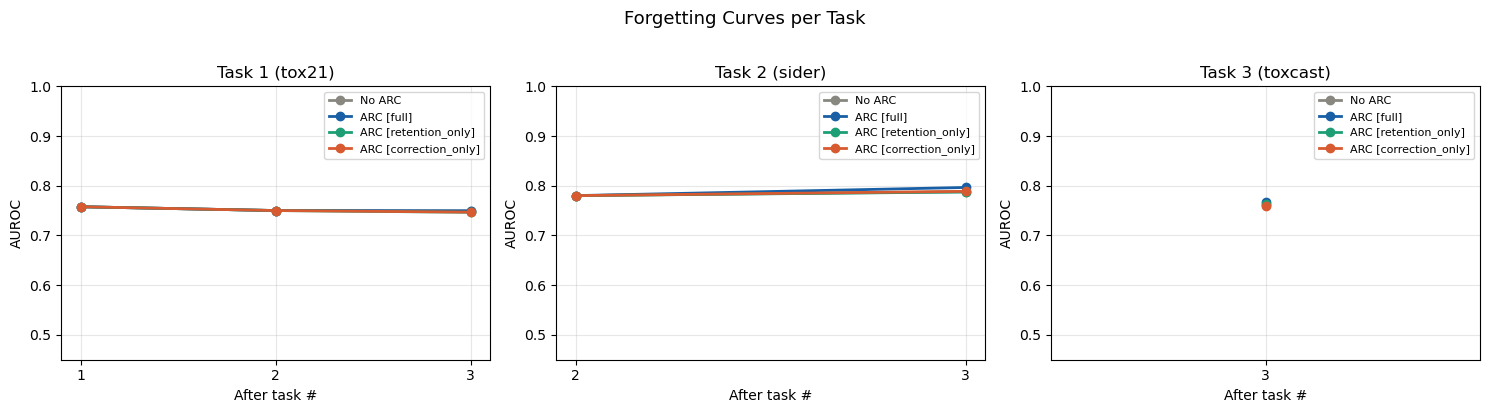

✅ Plot saved: forgetting_curves.png


In [30]:
# ============================================================
# CELL 26 — FORGETTING CURVE PLOT
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

T = len(task_splits)

fig, axes = plt.subplots(1, T, figsize=(5 * T, 4), sharey=False)
if T == 1:
    axes = [axes]

colors = {"no_arc": "#888780", "full": "#185FA5",
          "retention_only": "#1D9E75", "correction_only": "#D85A30"}

for task_i in range(T):
    ax = axes[task_i]
    for mode, res in results.items():
        R = res["R_matrix"]
        # Performance on task_i after each training step
        perf = []
        for t in range(task_i, T):
            val = R[t][task_i]
            if val is not None:
                perf.append((t + 1, val))
        if perf:
            xs, ys = zip(*perf)
            label = "No ARC" if mode == "no_arc" else f"ARC [{mode}]"
            ax.plot(xs, ys, marker='o', label=label,
                    color=colors.get(mode, None), linewidth=2)

    ax.set_title(f"Task {task_i+1} ({task_splits[task_i][0].split('_')[0]})")
    ax.set_xlabel("After task #")
    ax.set_ylabel("AUROC")
    ax.set_xticks(range(task_i + 1, T + 1))
    ax.legend(fontsize=8)
    ax.set_ylim(0.45, 1.0)
    ax.grid(True, alpha=0.3)

plt.suptitle("Forgetting Curves per Task", fontsize=13, fontweight='normal', y=1.02)
plt.tight_layout()
plt.savefig("forgetting_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot saved: forgetting_curves.png")


In [31]:
# ============================================================
# CELL 27 — ARC TRIGGER STATISTICS
# ============================================================
print("📊 ARC trigger stats (from last run of 'full' mode):")
print(f"  Retention triggered : {arc_stats['retention']}")
print(f"  Correction triggered: {arc_stats['correction']}")
print(f"  Neither (no action) : {arc_stats['none']}")
total = sum(arc_stats.values())
if total > 0:
    print(f"\n  Retention rate : {arc_stats['retention']/total*100:.1f}%")
    print(f"  Correction rate: {arc_stats['correction']/total*100:.1f}%")
    print(f"  Pass-through   : {arc_stats['none']/total*100:.1f}%")


📊 ARC trigger stats (from last run of 'full' mode):
  Retention triggered : 0
  Correction triggered: 1983
  Neither (no action) : 5880

  Retention rate : 0.0%
  Correction rate: 25.2%
  Pass-through   : 74.8%


## 💾 Section 9: Save Model & Results

In [ ]:
# ============================================================
# CELL 28 — SAVE
# ============================================================
import json, torch

# Save classifier weights (backbone is pretrained, no need to save)
torch.save(trained_model.classifier.state_dict(), "arc_classifier.pt")
print("✅ Classifier saved: arc_classifier.pt")

# Save results (convert numpy floats for JSON)
def to_python(obj):
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    if isinstance(obj, list):
        return [to_python(x) for x in obj]
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    return obj

save_results = {k: to_python({kk: vv for kk, vv in v.items() if kk != "R_matrix"})
                for k, v in results.items()}

with open("arc_results.json", "w") as f:
    json.dump(save_results, f, indent=2)
print("✅ Results saved: arc_results.json")
print(json.dumps(save_results, indent=2))


In [ ]:
# ============================================================
# DIAGNOSTIC CELL 1: CHECK OTD ROUTING CORRECTNESS
# ============================================================

print("\n" + "="*70)
print("🔍 DIAGNOSTIC 1: OTD Detection Validation")
print("="*70)

def diagnose_otd():
    """
    Checks if OTD is correctly routing samples to Assumption 1 vs 2.
    Tests on a small batch from final task.
    """
    
    # Get a small test batch
    test_batch_size = min(100, len(test_df))
    test_sample = test_df.sample(n=test_batch_size, random_state=42)
    
    T = len(task_splits)
    task_boundaries_final = task_boundaries
    
    past_indices = [idx for t in range(T-1) for idx in task_boundaries_final[t]]
    curr_indices = task_boundaries_final[T-1]
    
    print(f"\nTest configuration:")
    print(f"  Total tasks: {T}")
    print(f"  Past task indices: {len(past_indices)} ({past_indices[:3]}...)")
    print(f"  Current task indices: {len(curr_indices)} ({curr_indices[:3]}...)")
    
    # Run inference on test batch
    trained_model.eval()
    assumption1_count = 0
    assumption2_count = 0
    neither_count = 0
    
    with torch.no_grad():
        for idx, row in test_sample.iterrows():
            smi = row["SMILES"]
            enc = tokenizer(
                smi, max_length=CONFIG["max_length"],
                padding="max_length", truncation=True, return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(DEVICE)
            attn_mask = enc["attention_mask"].to(DEVICE)
            
            logits = trained_model(input_ids, attn_mask)
            probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            
            predicted_idx = int(probs.argmax())
            c = probs[predicted_idx]
            
            # --- CHECK ASSUMPTION 1 ---
            if predicted_idx in past_indices and c > CONFIG["epsilon"]:
                assumption1_count += 1
            
            # --- CHECK ASSUMPTION 2 ---
            elif predicted_idx in curr_indices:
                c_hat = probs[past_indices].max()
                w = c / (c_hat + 1e-8)
                if w < CONFIG["theta"]:
                    assumption2_count += 1
                else:
                    neither_count += 1
            else:
                neither_count += 1
    
    total = test_batch_size
    print(f"\n🎯 Assumption Trigger Rates (on {total} samples):")
    print(f"  ✅ Assumption 1 (Retention): {assumption1_count} ({assumption1_count/total*100:.1f}%)")
    print(f"  ✅ Assumption 2 (Correction): {assumption2_count} ({assumption2_count/total*100:.1f}%)")
    print(f"  ⊘ Neither (Pass-through): {neither_count} ({neither_count/total*100:.1f}%)")
    
    # Diagnosis
    print("\n📋 Diagnosis:")
    if assumption1_count + assumption2_count < 5:
        print("  ⚠️ CRITICAL: Very few samples trigger ARC!")
        print("     → OTD routing may be broken")
        print("     → Check: Are past_indices correctly populated?")
        print(f"     → Check: CONFIG['epsilon']={CONFIG['epsilon']} may be too high")
        print(f"     → Check: CONFIG['theta']={CONFIG['theta']} may be too strict")
    else:
        print(f"  ✅ Good: {assumption1_count+assumption2_count} samples ({(assumption1_count+assumption2_count)/total*100:.1f}%) trigger ARC")
    
    return assumption1_count, assumption2_count, neither_count

assumption1_ct, assumption2_ct, neither_ct = diagnose_otd()


In [ ]:
# ============================================================
# DIAGNOSTIC CELL 2: VERIFY ENTROPY LOSS CORRECTNESS
# ============================================================

print("\n" + "="*70)
print("🔍 DIAGNOSTIC 2: Adaptive Retention Loss Validation")
print("="*70)

def diagnose_entropy_loss():
    """
    Checks if entropy minimization loss is implemented correctly.
    Paper requires: L_EM = -(p*log(p) + (1-p)*log(1-p)).mean()
    """
    
    # Create dummy probability vector
    p = torch.tensor([0.1, 0.5, 0.9, 0.99], device=DEVICE)
    
    # Method 1: SINGLE-SIDE entropy (WRONG)
    L_EM_wrong = -(p * torch.log(p.clamp(1e-7, 1-1e-7))).mean()
    
    # Method 2: FULL BINARY entropy (CORRECT per paper)
    p_clamped = p.clamp(1e-7, 1-1e-7)
    L_EM_correct = -(p_clamped * torch.log(p_clamped) + 
                     (1-p_clamped) * torch.log(1-p_clamped)).mean()
    
    print(f"\nTesting on probability vector: {p.detach().cpu().numpy()}")
    print(f"\n❌ WRONG (single-side):     L_EM = {L_EM_wrong.item():.4f}")
    print(f"✅ CORRECT (full binary):  L_EM = {L_EM_correct.item():.4f}")
    print(f"   Difference: {(L_EM_correct - L_EM_wrong).item():.4f}")
    
    print("\n📋 What to check in your code:")
    print("   Search for: 'L_EM = ' or 'entropy'")
    print("   ✅ Should see: (p * torch.log(p) + (1-p) * torch.log(1-p))")
    print("   ❌ Should NOT see: only '(p * torch.log(p))'")
    
    print("\n⚠️ If your implementation uses WRONG entropy:")
    print("   → Only penalizes confident predictions p≈1")
    print("   → Does NOT penalize anti-confident p≈0")
    print("   → Can significantly hurt performance on multi-label data")
    
    return L_EM_wrong.item(), L_EM_correct.item()

wrong_loss, correct_loss = diagnose_entropy_loss()


In [ ]:
# ============================================================
# DIAGNOSTIC CELL 3: VERIFY TSS (Task-based Softmax Score)
# ============================================================

print("\n" + "="*70)
print("🔍 DIAGNOSTIC 3: Task-based Softmax Score (TSS) Validation")
print("="*70)

def diagnose_tss():
    """
    Checks if TSS is using proper temperature scaling T^(t-i).
    Paper Definition 1: S_i = max softmax over task i with T^(t-i) scaling
    """
    
    # Create dummy logits for 3 tasks (5 labels each = 15 total)
    logits_np = np.array([
        1.0, 0.8, 0.5, 0.2, 0.1,     # Task 0 logits
        2.0, 1.5, 1.2, 0.8, 0.5,     # Task 1 logits  
        3.0, 2.5, 2.2, 1.8, 1.5      # Task 2 logits (current)
    ])
    
    task_boundaries = [
        [0, 1, 2, 3, 4],              # Task 0 indices
        [5, 6, 7, 8, 9],              # Task 1 indices
        [10, 11, 12, 13, 14]          # Task 2 indices
    ]
    
    T = len(task_boundaries)
    temperature = CONFIG["tss_temp"]
    
    print(f"\nTest configuration:")
    print(f"  Total tasks: {T}")
    print(f"  Labels per task: 5")
    print(f"  Temperature: {temperature}")
    print(f"  Logits: {logits_np}")
    
    # Method 1: WRONG (no temperature scaling)
    scores_wrong = []
    for i in range(T):
        task_logits = logits_np[task_boundaries[i]]
        softmax_task = np.exp(task_logits) / np.exp(task_logits).sum()
        scores_wrong.append(softmax_task.max())
    
    # Method 2: CORRECT (with T^(t-i) scaling per paper)
    scores_correct = []
    for i in range(T):
        power = T - i
        cum_idx = [idx for j in range(i+1) for idx in task_boundaries[j]]
        
        scaled = logits_np[cum_idx] / (temperature ** power)
        scaled = scaled - scaled.max()  # numerical stability
        
        exp_s = np.exp(scaled)
        softmax_cum = exp_s / exp_s.sum()
        
        n_prev = sum(len(task_boundaries[j]) for j in range(i))
        task_slice = softmax_cum[n_prev:n_prev+len(task_boundaries[i])]
        scores_correct.append(task_slice.max())
    
    print(f"\n❌ WRONG (no temperature): {np.array(scores_wrong)}")
    print(f"✅ CORRECT (T^(t-i) scaling): {np.array(scores_correct)}")
    
    print("\n📋 What to check in your code:")
    print("   Search for: 'tss_score' or 'temperature'")
    print(f"   ✅ Should see: '/ (temperature ** power)' where power = t - i")
    print("   ❌ Should NOT see: uniform temperature for all tasks")
    
    best_task_wrong = np.argmax(scores_wrong)
    best_task_correct = np.argmax(scores_correct)
    
    print(f"\n🎯 Predicted best task:")
    print(f"  ❌ Without TSS: Task {best_task_wrong}")
    print(f"  ✅ With TSS:    Task {best_task_correct}")
    
    if best_task_wrong != best_task_correct:
        print(f"\n⚠️ TSS changes the decision! Current task bias is corrected.")
    
    return scores_wrong, scores_correct

scores_wrong, scores_correct = diagnose_tss()


In [ ]:
   # ============================================================
# DIAGNOSTIC CELL 3.5: WHY IS ASSUMPTION 1 = 100%? Debug Analysis
# ============================================================

print("\n" + "="*70)
print("🔍 DEBUG: Analyzing Why Assumption 1 Trigger Rate = 100%")
print("="*70)

def debug_assumption1():
    """
    Checks:
    1. Are past_indices correctly populated?
    2. Are predicted classes actually in past_indices?
    3. What's the distribution of predicted class indices?
    4. Are test samples from past or current tasks?
    """
    
    test_batch_size = min(50, len(test_df))
    test_sample = test_df.sample(n=test_batch_size, random_state=42)
    
    T = len(task_splits)
    past_indices = [idx for t in range(T-1) for idx in task_boundaries[t]]
    curr_indices = task_boundaries[T-1]
    
    print(f"\n1️⃣ INDICES CHECK:")
    print(f"   Past indices: {len(past_indices)} labels → {past_indices[:5]}...{past_indices[-3:]}")
    print(f"   Curr indices: {len(curr_indices)} labels → {curr_indices[:5]}...{curr_indices[-3:]}")
    print(f"   Total labels: {len(past_indices) + len(curr_indices)}")
    print(f"   Overlap check: {len(set(past_indices) & set(curr_indices))} (should be 0)")
    
    # Collect predicted classes
    predicted_classes = []
    predicted_confidences = []
    
    trained_model.eval()
    with torch.no_grad():
        for idx, row in test_sample.iterrows():
            smi = row["SMILES"]
            enc = tokenizer(
                smi, max_length=CONFIG["max_length"],
                padding="max_length", truncation=True, return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(DEVICE)
            attn_mask = enc["attention_mask"].to(DEVICE)
            
            logits = trained_model(input_ids, attn_mask)
            probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            
            predicted_idx = int(probs.argmax())
            predicted_classes.append(predicted_idx)
            predicted_confidences.append(probs[predicted_idx])
    
    predicted_classes = np.array(predicted_classes)
    predicted_confidences = np.array(predicted_confidences)
    
    print(f"\n2️⃣ PREDICTED CLASS DISTRIBUTION:")
    print(f"   Min predicted class: {predicted_classes.min()}")
    print(f"   Max predicted class: {predicted_classes.max()}")
    print(f"   Range: [{predicted_classes.min()}, {predicted_classes.max()}]")
    print(f"   Past indices range: [{min(past_indices)}, {max(past_indices)}]")
    print(f"   Curr indices range: [{min(curr_indices)}, {max(curr_indices)}]")
    
    in_past = sum(1 for pc in predicted_classes if pc in past_indices)
    in_curr = sum(1 for pc in predicted_classes if pc in curr_indices)
    
    print(f"\n3️⃣ PREDICTED CLASS LOCATION:")
    print(f"   Predicted in PAST indices: {in_past}/{test_batch_size} ({in_past/test_batch_size*100:.1f}%)")
    print(f"   Predicted in CURR indices: {in_curr}/{test_batch_size} ({in_curr/test_batch_size*100:.1f}%)")
    print(f"   (Other/unmatched): {test_batch_size - in_past - in_curr}")
    
    print(f"\n4️⃣ CONFIDENCE DISTRIBUTION:")
    print(f"   Mean confidence: {predicted_confidences.mean():.4f}")
    print(f"   Min confidence: {predicted_confidences.min():.4f}")
    print(f"   Max confidence: {predicted_confidences.max():.4f}")
    print(f"   > epsilon (0.75): {sum(predicted_confidences > CONFIG['epsilon'])}/{test_batch_size}")
    print(f"   < epsilon (0.75): {sum(predicted_confidences <= CONFIG['epsilon'])}/{test_batch_size}")
    
    print(f"\n5️⃣ ROOT CAUSE ANALYSIS:")
    
    if in_past == test_batch_size:
        print("   ⚠️ ISSUE FOUND: ALL predicted classes are in past_indices!")
        print(f"      → Model has collapsed to predicting only past task classes")
        print(f"      → This means classifier hasn't learned current task well")
        print(f"      → OR training data heavily imbalanced towards past tasks")
        
    if predicted_confidences.mean() > CONFIG["epsilon"]:
        print(f"   ⚠️ ISSUE FOUND: High mean confidence ({predicted_confidences.mean():.4f} > {CONFIG['epsilon']})")
        print(f"      → Almost all predictions have c > epsilon")
        print(f"      → Model is overconfident on predictions")

debug_assumption1()
